In [9]:
# Dual-layer Statistical Analysis - phantom head data

import seaborn as sns
import pandas as pd
import os
import pingouin as pg
import matplotlib.pyplot as plt
import numpy as np
import ptitprince as pt


file_path = "C:/Users/melan/Desktop/duallayer_stats/"
pathout = 'C:/Users/melan/Desktop/duallayer_stats/results/'
os.chdir(file_path)

my_palette = ['#EC5800', '#0F52BA']

df = pd.read_csv(os.path.join(file_path, 'ERP_PH_SNRs_single.txt'), sep=",")
df["ID"] = df["ID"].astype("category")

df = df.sort_values(["Measurement", "Pipeline"]) 


df["trial_within_pipeline"] = (
    df.groupby(["Measurement", "Pipeline"])
      .cumcount()
)

df["TrialID"] = (
    df.groupby("Measurement")["trial_within_pipeline"]
      .transform(lambda x: x)
)


c:\Users\melan\AppData\Local\Programs\Python\Python313\Lib\site-packages\ptitprince\PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):


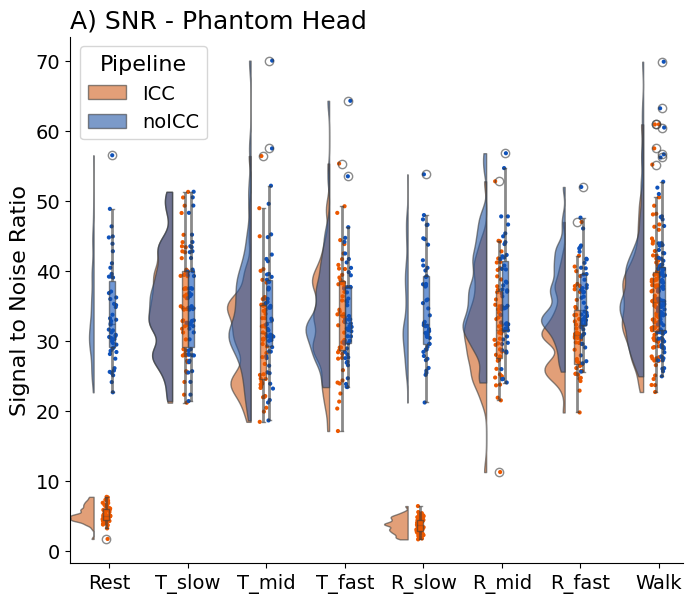

In [10]:
# Plot data - SNR

measurement_order = ['rest', 'slow_trans', 'mid_trans', 'fast_trans', 'slow_roll', 'mid_roll', 'fast_roll', 'walk']
pipeline_order = ['ICC', 'trad']

df['Measurement'] = pd.Categorical(df['Measurement'], categories=measurement_order, ordered=True)
df['Pipeline'] = pd.Categorical(df['Pipeline'], categories=pipeline_order, ordered=True)


fig1, ax = plt.subplots(figsize=(8,6))

pt.RainCloud(
    data=df,
    x="Measurement",
    y="SNR",
    hue="Pipeline",
    palette=my_palette,
    dodge=True,
    width_viol=.6,
    alpha=.6,
    orient="v",
    ax=ax
)

sns.despine()
plt.tight_layout()


plt.ylabel("Signal to Noise Ratio", fontsize=16)
plt.xlabel("", fontsize=10)
plt.title("A) SNR - Phantom Head", loc='left', fontsize = 18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax.legend(title="Pipeline", labels=["ICC", "noICC"], fontsize=14, title_fontsize=16)
ax.set_xticklabels(labels=['Rest', 'T_slow', 'T_mid', 'T_fast', 'R_slow', 'R_mid', 'R_fast', 'Walk'])


os.chdir(pathout)
fig1.savefig("phantom_head_SNR.png", dpi=300, bbox_inches='tight')
fig1.savefig("phantom_head_SNR.svg", dpi=300, bbox_inches='tight')

In [ ]:
# Stats - SNR

stats = (
    df.groupby(['Pipeline', 'Measurement'])['SNR']
      .agg(mean='mean', sd='std', n='count')
      .reset_index()
)

print(stats)

my_aov = pg.mixed_anova(data = df, dv = 'SNR',  within = 'Pipeline',
                        between = 'Measurement', subject = 'ID')
my_aov.round(3)


In [ ]:
# pipeline comparison

condition_order = df['Measurement'].unique()

df['Measurement'] = pd.Categorical(
    df['Measurement'],
    categories=condition_order,
    ordered=True
)

df_wide = df.pivot_table(index='Measurement', columns='Pipeline', values='SNR', aggfunc = 'mean').reset_index()

#%%

df_wide['diff'] = df_wide['trad'] - df_wide['ICC']

mean_diff = df_wide['diff'].mean()
sem_diff = df_wide['diff'].std(ddof=1) / np.sqrt(len(df))

ci95 = 1.96 * sem_diff

# Optional: repeated-measures Cohen's dz
cohens_dz = mean_diff / df_wide['diff'].std(ddof=1)

#%% plot with both

my_y = np.arange(len(df_wide))
fig, ax = plt.subplots(figsize=(4, 6))

# -------------------------------------------------------
# Standing points
# -------------------------------------------------------

ax.scatter(
    df_wide['diff'],
    my_y,
    s=60,
    color = 'lightslategray'
)


# -------------------------------------------------------
# Zero reference line
# -------------------------------------------------------

ax.axvline(0, linestyle='--', color = 'k')


# -------------------------------------------------------
# Labels
# -------------------------------------------------------

ax.set_yticks(my_y)
ax.set_yticklabels(df_wide['Measurement'])

ax.set_xlabel('SNR difference (trad - ICC) [µV]')
ax.set_ylabel('Measurement')

ax.set_title('Measurement-wise preprocessing differences')

ax.legend(frameon=False, loc = 'lower left')

# Optional axis limits
ax.set_xlim(-35, 35)

ax.text(
    0.02,
    0.05,
    f"mean \u0394 = {mean_diff:.2f} µV\n",
    transform=ax.transAxes,
    verticalalignment='bottom'
)


# Cleaner appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#%%
os.chdir(pathout)
fig.savefig("phantomHead_pipelineComp_diffs.svg", dpi=300, bbox_inches='tight')



In [7]:
# load & prepare - ICs

df = pd.read_csv(os.path.join(file_path, 'Gerd_DF_RV.txt'), sep=",")
df['RV'] = df['RV']*100

(array([7. , 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8. ]),
 [Text(0, 7.0, '7.0'),
  Text(0, 7.1, '7.1'),
  Text(0, 7.2, '7.2'),
  Text(0, 7.3, '7.3'),
  Text(0, 7.4, '7.4'),
  Text(0, 7.5, '7.5'),
  Text(0, 7.6, '7.6'),
  Text(0, 7.7, '7.7'),
  Text(0, 7.8, '7.8'),
  Text(0, 7.9, '7.9'),
  Text(0, 8.0, '8.0')])

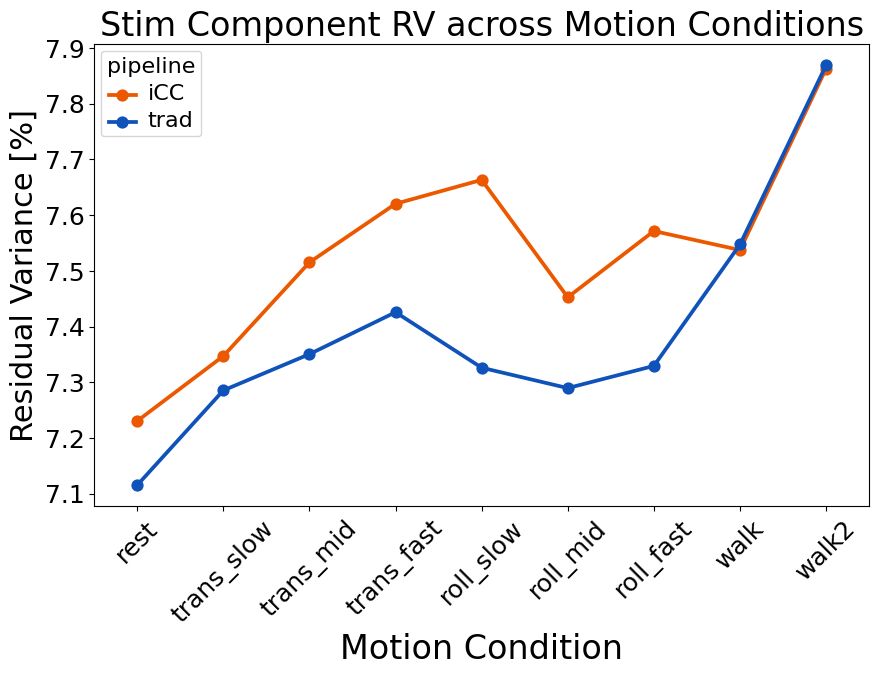

In [8]:
# plot data - ICs

fig2 = plt.figure(figsize=(10, 6))
ax = sns.pointplot(data = df, x = 'cond', y = 'RV', hue = 'pipeline',
                   palette=my_palette)
sns.move_legend(ax, 'upper left')
plt.setp(ax.get_legend().get_texts(), fontsize='16')
plt.setp(ax.get_legend().get_title(), fontsize='16')


plt.ylabel("Residual Variance [%]",fontsize=22)
plt.xlabel("Motion Condition", fontsize=24)
plt.title("Stim Component RV across Motion Conditions", fontsize = 24)
plt.xticks(fontsize=18)
plt.xticks(rotation=45)
plt.yticks(fontsize=18)

#os.chdir(pathout)
#fig2.savefig("phantom_head_comps.png", dpi=300, bbox_inches='tight')



C:\Users\melan\AppData\Local\Temp\ipykernel_6272\634931522.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_wide = df.pivot_table(index='Measurement', columns='Pipeline', values='SNR', aggfunc = 'mean').reset_index()
C:\Users\melan\AppData\Local\Temp\ipykernel_6272\634931522.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc = 'lower left')


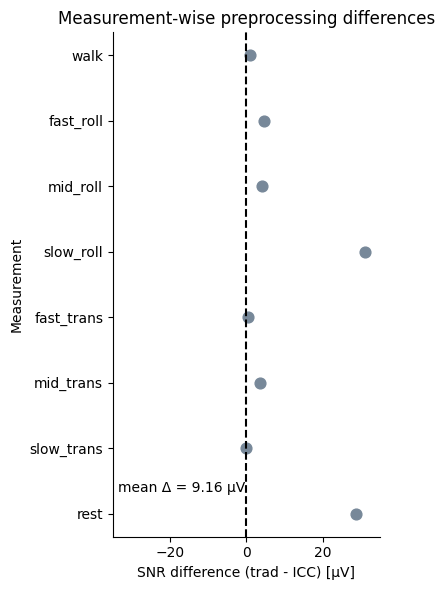

In [ ]:
# correlations ?

from scipy.stats import pearsonr

# -------------------------------------------------------
# Variables
# -------------------------------------------------------

x = df_wide['all_mean_corrs']
y = df_wide['diff']
subjects = df_wide['Measurement']

# -------------------------------------------------------
# Correlations
# -------------------------------------------------------

r, p = pearsonr(x, y)

# -------------------------------------------------------
# Generate participant colors
# -------------------------------------------------------

cmap = plt.cm.tab20
colors = plt.cm.tab20(np.linspace(0, 1, len(df)))

# -------------------------------------------------------
# Figure
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(5, 4))

# -------------------------------------------------------
# Scatter
# -------------------------------------------------------

ax.scatter(
    x,
    y,
    s=60,
    linewidth=0.5
)


# -------------------------------------------------------
# Regression line
# -------------------------------------------------------

m, b = np.polyfit(x, y, 1)

xx = np.linspace(x.min(), x.max(), 100)

ax.plot(
    xx,
    m * xx + b,
    color='k',
    linewidth=2
)


# -------------------------------------------------------
# Labels
# -------------------------------------------------------

ax.set_xlabel('Mean scalp–noise correlation')

ax.set_ylabel('ERP amplitude difference\n(trad - ICC) [µV]')

ax.set_title('Phantom head measurements')

# -------------------------------------------------------
# Statistics text
# -------------------------------------------------------

ax.text(
    0.05,
    0.95,
    f'r = {r:.2f}\np = {p:.3f}',
    transform=ax.transAxes,
    verticalalignment='top'
)

# -------------------------------------------------------
# Appearance
# -------------------------------------------------------

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()